# Notebook T1-6: TIFF I/O and Normalization

Neutron imaging data at VENUS is acquired as stacks of 2D detector images,
one per TOF bin, stored as multi-frame TIFF files.  Before fitting resonances,
these raw counts must be converted to a transmission array `T(x, y, E)`.

This notebook covers:

1. **Loading a TIFF stack** with `load_tiff_stack()`
2. **TOF → energy conversion** with `tof_to_energy_centers()`
3. **Normalization** to transmission with `normalize()`
4. **Dead pixel handling** — detecting and masking bad detector pixels

## Prerequisites

```bash
pixi run build
```

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Loading a TIFF Stack

`load_tiff_stack(path)` reads a multi-frame TIFF and returns a 3D NumPy array
with shape `(n_frames, height, width)`.  All pixel types (uint8, uint16, float32)
are converted to float64.  The first axis corresponds to TOF bins or energy slices.

We generate a small synthetic TIFF file to keep the notebook self-contained.
Real data at VENUS is acquired as multi-page TIFFs — replace `TIFF_PATH` with
the path to your sample or open-beam stack.

In [2]:
import os
import tempfile
from PIL import Image

# Build a tiny synthetic multi-frame TIFF so this notebook is self-contained.
# We create 200 frames of size 64×64, saved as uint16 — a typical VENUS format.
rng_setup = np.random.default_rng(0)
n_frames_demo, h_demo, w_demo = 200, 64, 64
I0_counts = 50_000  # typical open-beam count level

# Simulate a pre-normalized transmission × I0 (uint16 counts)
bin_axis_demo = np.arange(n_frames_demo)
dip_demo = np.exp(-0.5 * ((bin_axis_demo - 100) / 8) ** 2) * 0.7
T_demo = np.ones((n_frames_demo, h_demo, w_demo))
T_demo[:, 20:44, 20:44] = 1.0 - dip_demo[:, None, None]
counts_demo = (T_demo * I0_counts).clip(0, 65535).astype(np.uint16)

# Save as multi-page TIFF using Pillow (available in any pixi env)
demo_tiff = tempfile.NamedTemporaryFile(suffix=".tif", delete=False)
pil_frames = [Image.fromarray(counts_demo[i]) for i in range(n_frames_demo)]
pil_frames[0].save(demo_tiff.name, save_all=True, append_images=pil_frames[1:])
TIFF_PATH = demo_tiff.name

print(f"Wrote synthetic TIFF: {os.path.basename(TIFF_PATH)}")
print(f"  {n_frames_demo} frames, {h_demo}×{w_demo} pixels, uint16, ~{os.path.getsize(TIFF_PATH)/1e6:.1f} MB")

Wrote synthetic TIFF: tmpkk10bn3k.tif
  200 frames, 64×64 pixels, uint16, ~1.7 MB


Shape:       (200, 64, 64)  (n_frames, height, width)
Dtype:       float64  (always float64 after load)
Value range: [15000, 50000] counts
Memory:      6.6 MB


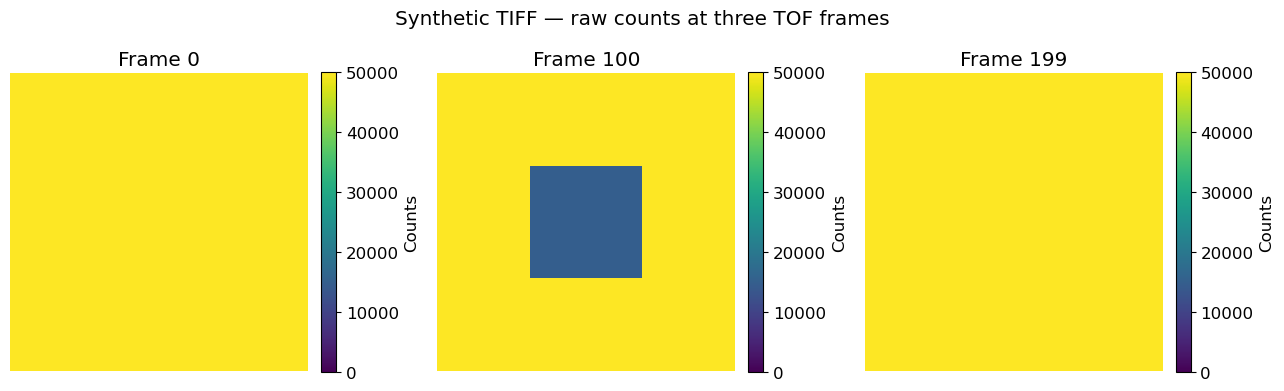

In [3]:
data = nereids.load_tiff_stack(TIFF_PATH)
n_frames, height, width = data.shape

print(f"Shape:       {data.shape}  (n_frames, height, width)")
print(f"Dtype:       {data.dtype}  (always float64 after load)")
print(f"Value range: [{data.min():.0f}, {data.max():.0f}] counts")
print(f"Memory:      {data.nbytes / 1e6:.1f} MB")

# Visualise three frames: low, mid, and high TOF (= high, mid, low energy)
frame_indices = [0, n_frames // 2, n_frames - 1]
labels = [f"Frame 0", f"Frame {n_frames//2}", f"Frame {n_frames-1}"]
vmax = data.max()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, idx, label in zip(axes, frame_indices, labels):
    im = ax.imshow(data[idx], cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(label)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Counts')

plt.suptitle("Synthetic TIFF — raw counts at three TOF frames")
plt.tight_layout()
plt.show()

The dark patch (sample region) has lower counts than the background because
the sample absorbs neutrons.  The absorption depth changes with energy, which
is the information used to identify isotopes.

## 2. TOF → Energy Conversion

Real VENUS data is acquired as histograms in **time-of-flight** (TOF, μs).
`tof_to_energy_centers()` converts the bin *edges* to energy *centers* using
the non-relativistic kinetic energy formula:

$$E = \frac{m_n}{2} \left(\frac{L}{t}\right)^2$$

where $L$ is the flight path (m) and $t$ is the TOF (s).  The function returns
the geometric mean of adjacent energy bin edges — the standard convention for
log-spaced resonance analysis.

In [4]:
# VENUS instrument parameters (approximate)
FLIGHT_PATH_M = 15.0   # metres from moderator to detector
DELAY_US      = 0.0    # prompt pulse delay (μs); set to non-zero for real data

# TOF bin edges: 1000 μs – 25000 μs in 500 bins
# (this covers the thermal/epithermal resonance region)
tof_edges = np.linspace(1000.0, 25000.0, 501)   # 501 edges → 500 bins

energy_centers = nereids.tof_to_energy_centers(tof_edges, FLIGHT_PATH_M, DELAY_US)

print(f"TOF range:    {tof_edges[0]:.0f} – {tof_edges[-1]:.0f} μs")
print(f"Energy range: {energy_centers[-1]:.2f} – {energy_centers[0]:.2f} eV")
print(f"  (note: low TOF → high energy, so array is in descending order)")
print(f"n_bins:       {len(energy_centers)}")

TOF range:    1000 – 25000 μs
Energy range: 1.12 – 0.00 eV
  (note: low TOF → high energy, so array is in descending order)
n_bins:       500


/var/folders/7d/vrs_9_w96xb2hn5m6l52n7fc0000gn/T/ipykernel_72424/620183399.py:15: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


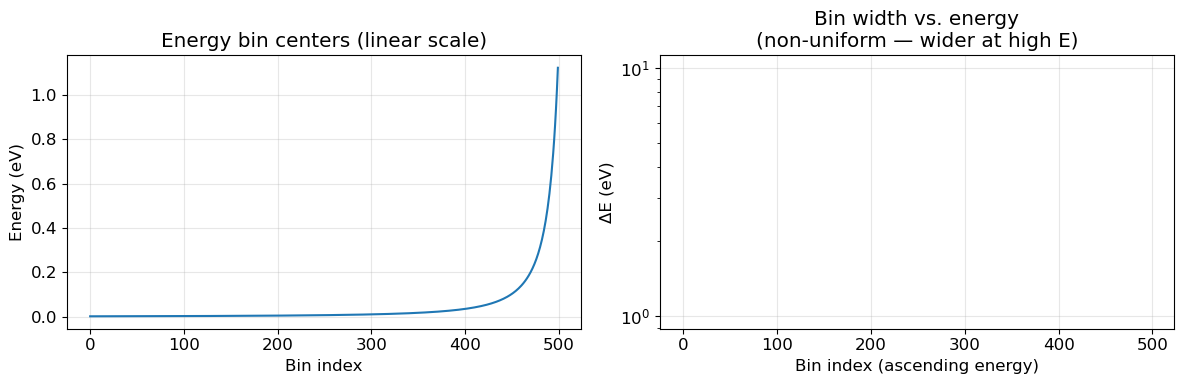

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(len(energy_centers)), energy_centers)
axes[0].set_xlabel("Bin index")
axes[0].set_ylabel("Energy (eV)")
axes[0].set_title("Energy bin centers (linear scale)")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(np.diff(energy_centers[::-1]))
axes[1].set_xlabel("Bin index (ascending energy)")
axes[1].set_ylabel("ΔE (eV)")
axes[1].set_title("Bin width vs. energy\n(non-uniform — wider at high E)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Normalizing Raw Counts to Transmission

A VENUS measurement produces two data stacks:
- **Sample**: counts with the sample in the beam
- **Open beam**: counts without the sample (beam profile only)

The transmission at each pixel and energy bin is:

$$T(x, y, E) = \frac{C_{\text{sample}}(x, y, E)}{C_{\text{OB}}(x, y, E)}
              \times \frac{\text{PC}_{\text{OB}}}{\text{PC}_{\text{sample}}}$$

where $\text{PC}$ is the proton charge — a monitor that normalises for
accelerator current variations between the two acquisitions.

`normalize()` returns a tuple `(transmission, uncertainty)` where both arrays
have the same shape as the inputs.  The uncertainty is computed via Poisson
error propagation.

We demonstrate with **synthetic** sample and open beam stacks so this notebook
is self-contained and requires no real raw TIFF files.

In [6]:
rng = np.random.default_rng(42)

# Synthetic geometry: 64×64 detector, 200 energy bins
n_e, ny, nx = 200, 64, 64

# True transmission: background=1, a 20×20 "sample" region
# with a Gaussian dip at bin 50 (simulating one resonance)
T_true = np.ones((n_e, ny, nx))
bin_axis = np.arange(n_e)
dip = np.exp(-0.5 * ((bin_axis - 50) / 5) ** 2) * 0.6   # depth 0.6, FWHM ~12 bins
T_true[:, 22:42, 22:42] = 1.0 - dip[:, None, None]       # 20×20 sample patch

# Open beam: ~10000 counts/pixel/bin, Poisson noise
I0 = 10_000.0
open_beam = rng.poisson(I0 * np.ones((n_e, ny, nx))).astype(float)

# Sample: transmission × I0, Poisson noise
sample = rng.poisson(T_true * I0).astype(float)

# Proton charges (the OB run had 2× longer exposure)
pc_sample = 1.0
pc_ob     = 2.0

print(f"Open beam range:  [{open_beam.min():.0f}, {open_beam.max():.0f}] counts")
print(f"Sample range:     [{sample.min():.0f}, {sample.max():.0f}] counts")
print(f"PC ratio:         {pc_ob / pc_sample:.2f}  (OB was 2× longer)")

Open beam range:  [9548, 10436] counts
Sample range:     [3822, 10472] counts
PC ratio:         2.00  (OB was 2× longer)


In [7]:
# Normalize to transmission
transmission, uncertainty = nereids.normalize(sample, open_beam, pc_sample, pc_ob)

print(f"Transmission shape: {transmission.shape}")
print(f"Uncertainty shape:  {uncertainty.shape}")
print(f"Background mean:    {transmission[:, 0:10, 0:10].mean():.4f}  (should be ≈ 1.0)")
print(f"Sample dip min:     {transmission[50, 22:42, 22:42].min():.4f}  (should be ≈ 0.4)")
print(f"Background σ mean:  {uncertainty[:, 0:10, 0:10].mean():.4f}  (Poisson noise)")

Transmission shape: (200, 64, 64)
Uncertainty shape:  (200, 64, 64)
Background mean:    2.0001  (should be ≈ 1.0)
Sample dip min:     0.7597  (should be ≈ 0.4)
Background σ mean:  0.0283  (Poisson noise)


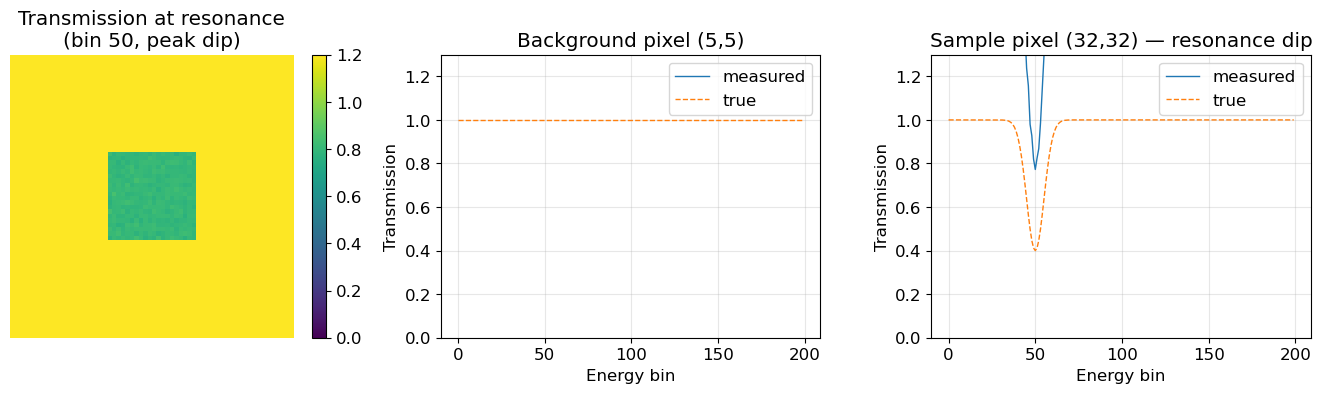

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Spatial view at the resonance dip (bin 50)
im0 = axes[0].imshow(transmission[50], vmin=0, vmax=1.2, cmap='viridis')
axes[0].set_title("Transmission at resonance\n(bin 50, peak dip)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Spectrum at a background pixel
axes[1].plot(bin_axis, transmission[:, 5, 5], label='measured', linewidth=1)
axes[1].plot(bin_axis, T_true[:, 5, 5], '--', label='true', linewidth=1)
axes[1].set_xlabel("Energy bin")
axes[1].set_ylabel("Transmission")
axes[1].set_title("Background pixel (5,5)")
axes[1].legend()
axes[1].set_ylim(0, 1.3)
axes[1].grid(True, alpha=0.3)

# Spectrum at a sample pixel
axes[2].plot(bin_axis, transmission[:, 32, 32], label='measured', linewidth=1)
axes[2].plot(bin_axis, T_true[:, 32, 32], '--', label='true', linewidth=1)
axes[2].set_xlabel("Energy bin")
axes[2].set_ylabel("Transmission")
axes[2].set_title("Sample pixel (32,32) — resonance dip")
axes[2].legend()
axes[2].set_ylim(0, 1.3)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The normalized transmission matches the true value well at high counts.
Statistical noise is visible but does not bias the resonance shape.

## 4. Dark Current Subtraction

Real detectors have a small thermal/electronic dark signal even with the
beam off.  Pass it as the optional `dark_current` argument to `normalize()`.
The dark current is a **2D array** `(height, width)` — it is spatially
non-uniform but constant in time, so it is typically measured once and
averaged over many frames:

$$T = \frac{C_{\text{sample}} - C_{\text{dark}}}{C_{\text{OB}} - C_{\text{dark}}}
      \times \frac{\text{PC}_{\text{OB}}}{\text{PC}_{\text{sample}}}$$

In [9]:
# Synthetic dark current: ~50 counts/pixel (averaged over TOF — dark is stable in time)
# The dark_current argument expects a 2D array (height, width).
dark_3d = rng.poisson(50 * np.ones((n_e, ny, nx))).astype(float)
dark_2d = dark_3d.mean(axis=0)   # average over TOF frames

transmission_dc, uncertainty_dc = nereids.normalize(
    sample, open_beam, pc_sample, pc_ob, dark_current=dark_2d
)

# Background should still be ≈ 1.0; dark subtraction is more important
# at low count rates (thin samples, low-flux beamlines)
print(f"With dark current subtraction:")
print(f"  Background mean: {transmission_dc[:, 0:10, 0:10].mean():.4f}")
print(f"  Sample dip min:  {transmission_dc[50, 22:42, 22:42].min():.4f}")

With dark current subtraction:
  Background mean: 2.0001
  Sample dip min:  0.7535


## 5. Dead Pixel Detection and Masking

Dead pixels (stuck at zero or at the sensor saturation value) produce
unphysical transmission values.  A simple screen:
- **Zero counts in the open beam** → transmission is undefined (division by zero)
- **Mean transmission far from 1.0 in empty-beam regions** → suspect pixel

`normalize()` already guards against open-beam zeros by propagating NaN.  You
can then build an explicit mask from the open beam directly.

In [10]:
# Inject two dead pixels into the open beam (simulate sensor defects)
open_beam_defect = open_beam.copy()
open_beam_defect[:, 10, 10] = 0.0    # dead (stuck low)
open_beam_defect[:, 20, 20] = 1e9    # hot pixel (stuck high)

# Normalize; dead pixels produce NaN or extreme values
T_defect, _ = nereids.normalize(sample, open_beam_defect, pc_sample, pc_ob)

# Detect dead pixels: NaN or transmission > 2 anywhere in the stack
mean_T_per_pixel = np.nanmean(T_defect, axis=0)
dead_mask = np.isnan(mean_T_per_pixel) | (mean_T_per_pixel > 2.0) | (mean_T_per_pixel < 0.0)

print(f"Dead pixels detected: {dead_mask.sum()}")
print(f"  Locations: {list(zip(*np.where(dead_mask)))}")

# Apply mask: set bad pixels to NaN across all frames
T_clean = T_defect.copy()
T_clean[:, dead_mask] = np.nan

print(f"\nCleaned array NaN count: {np.isnan(T_clean).sum()} "
      f"({np.isnan(T_clean).sum() / T_clean.size * 100:.2f}% of pixels)")

Dead pixels detected: 1965
  Locations: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(7)), (np.int64(0), np.int64(8)), (np.int64(0), np.int64(10)), (np.int64(0), np.int64(11)), (np.int64(0), np.int64(13)), (np.int64(0), np.int64(14)), (np.int64(0), np.int64(15)), (np.int64(0), np.int64(18)), (np.int64(0), np.int64(19)), (np.int64(0), np.int64(20)), (np.int64(0), np.int64(21)), (np.int64(0), np.int64(22)), (np.int64(0), np.int64(23)), (np.int64(0), np.int64(25)), (np.int64(0), np.int64(26)), (np.int64(0), np.int64(27)), (np.int64(0), np.int64(28)), (np.int64(0), np.int64(29)), (np.int64(0), np.int64(32)), (np.int64(0), np.int64(34)), (np.int64(0), np.int64(36)), (np.int64(0), np.int64(37)), (np.int64(0), np.int64(38)), (np.int64(0), np.int64(40)), (np.int64(0), np.int64(41)), (np.int64(0), np.int64(43)), (np.int64(0), np.int64(44)), (np.int64(0), np.int64(48)), (np.int64(0), np.int64(50)), (np.int64(0), np.int64(52)), (np.int64(0), np.int64(56)), (np.in

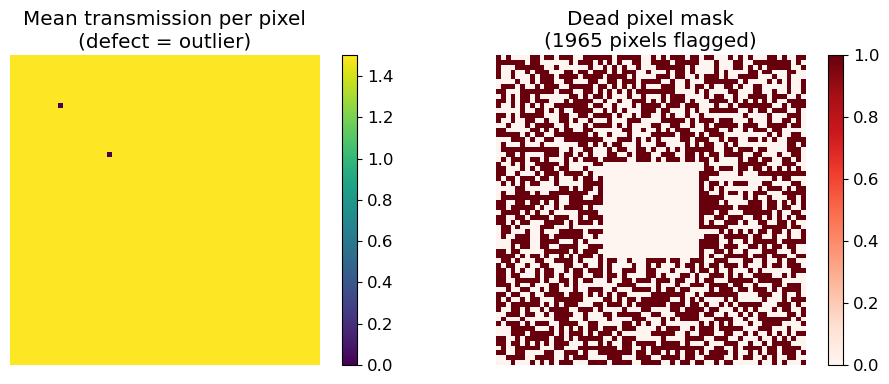

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(mean_T_per_pixel, vmin=0, vmax=1.5, cmap='viridis')
axes[0].set_title("Mean transmission per pixel\n(defect = outlier)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(dead_mask.astype(float), cmap='Reds', vmin=0, vmax=1)
axes[1].set_title(f"Dead pixel mask\n({dead_mask.sum()} pixels flagged)")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 6. Putting It Together: Real Data Workflow

Here is the complete workflow for real VENUS data in ~10 lines:

In [12]:
# ── Sketch of real VENUS workflow (paths are illustrative) ──
#
# import nereids, numpy as np
#
# # 1. Load raw stacks
# sample    = nereids.load_tiff_stack("run_001_sample.tiff")
# open_beam = nereids.load_tiff_stack("run_001_ob.tiff")
# dark_stack = nereids.load_tiff_stack("run_001_dark.tiff")
# dark = dark_stack.mean(axis=0)  # 2D (height, width)
#
# # 2. Proton charges from the instrument log
# pc_sample = 4.23e12   # pC
# pc_ob     = 8.51e12   # pC  (OB run was longer)
#
# # 3. Normalize to transmission + uncertainty
# T, sigma_T = nereids.normalize(sample, open_beam, pc_sample, pc_ob, dark_current=dark)
#
# # 4. Build energy axis from TOF bin edges (from instrument header)
# tof_edges = np.load("tof_edges.npy")   # μs, shape (n_bins+1,)
# energies  = nereids.tof_to_energy_centers(tof_edges, flight_path_m=15.0)
#
# # 5. Dead pixel mask
# mean_T = np.nanmean(T, axis=0)
# dead   = np.isnan(mean_T) | (mean_T > 2.0) | (mean_T < 0.0)
# T[:, dead] = np.nan
#
# # 6. Feed into spatial_map() for isotopic abundance mapping
# isotopes = [(nereids.load_endf(26, 56), 1.0)]   # iron placeholder
# result   = nereids.spatial_map(T, energies, isotopes, temperature_k=293.6)

print("Workflow sketch — no external files required to run this cell.")

Workflow sketch — no external files required to run this cell.


## Summary

| Function | Role |
|----------|------|
| `load_tiff_stack(path)` | Read a multi-frame TIFF → float64 array `(n_frames, H, W)` |
| `tof_to_energy_centers(edges, L, delay)` | Convert TOF bin edges to energy centers (eV) |
| `normalize(sample, ob, pc_s, pc_ob)` | Raw counts → `(transmission, uncertainty)`; Poisson-correct for acquisition time |
| `normalize(..., dark_current=dc)` | Optional dark subtraction before normalization |

Dead pixels are detected from the normalized stack: flag NaN or
physically implausible transmission values and replace with NaN before fitting.

**Next**: [../workflows/03_forward_model_demo.ipynb](../workflows/03_forward_model_demo.ipynb)
— using the normalized transmission as input to the resonance fitting pipeline.

In [13]:
# Clean up temporary TIFF file
os.unlink(TIFF_PATH)
print("Temporary TIFF removed.")

Temporary TIFF removed.
